In [1]:
import matplotlib.pyplot as plt

from src.disorder import generate_breakdown_strength
from src.config import SimulationConfig
from src.field import ElectricField
from src.growth import get_front, get_growth_probabilities

In [2]:
strength = generate_breakdown_strength(
    ny=128,
    nx=128,
    correlation_length=5.0,
    weibull_shape=5.0,
    seed=42,
)

print("mean:", strength.mean())
print("std:", strength.std())
print("min:", strength.min())
print("max:", strength.max())

mean: 1.0006881830857728
std: 0.22805282868761773
min: 0.12394788826522815
max: 1.6956643976400796


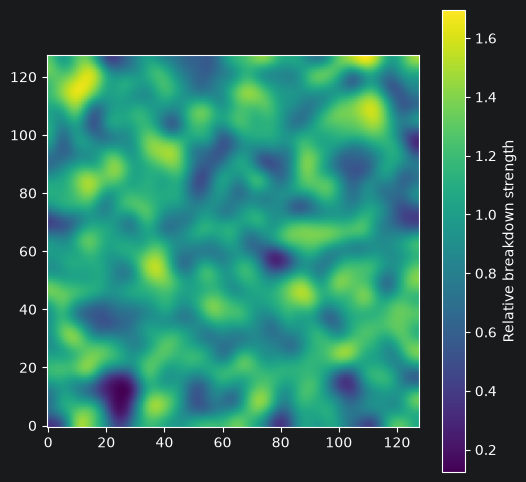

In [3]:
plt.figure(figsize=(6, 6))

plt.imshow(
    strength,
    origin="lower",
)

plt.colorbar(
    label="Relative breakdown strength"
)

plt.show()

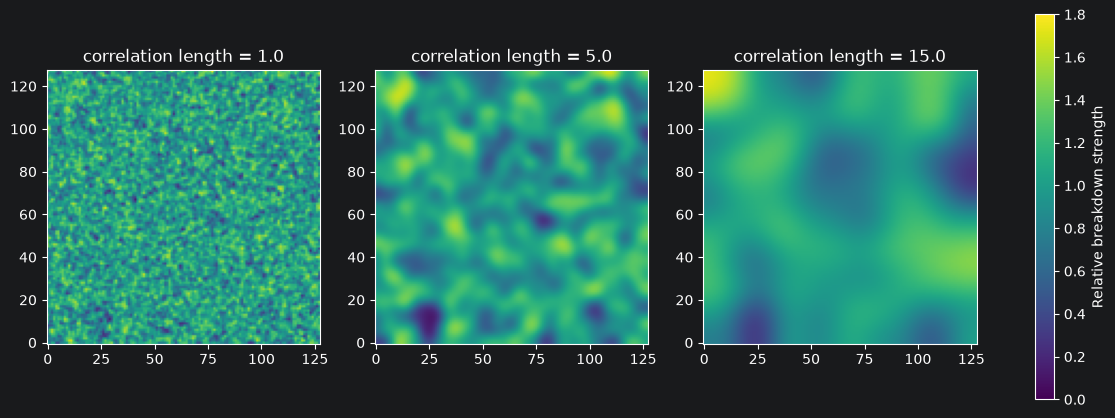

In [4]:
correlation_lengths = [1.0, 5.0, 15.0]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, lc in zip(axes, correlation_lengths):
    strength = generate_breakdown_strength(
        ny=128,
        nx=128,
        correlation_length=lc,
        weibull_shape=5.0,
        seed=42,
    )

    image = ax.imshow(
        strength,
        origin="lower",
        vmin=0.0,
        vmax=1.8,
    )

    ax.set_title(
        f"correlation length = {lc}"
    )

plt.colorbar(
    image,
    ax=axes,
    label="Relative breakdown strength",
)

plt.show()

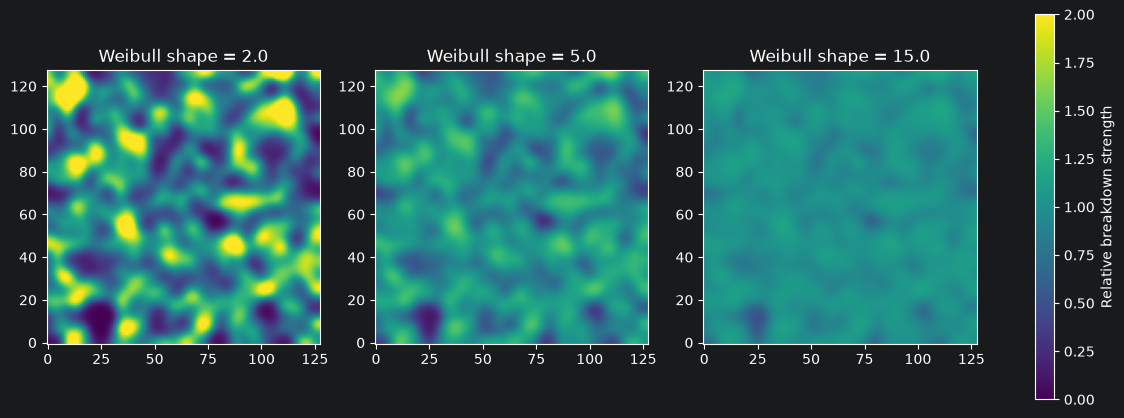

In [5]:
weibull_shapes = [2.0, 5.0, 15.0]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, k in zip(axes, weibull_shapes):
    strength = generate_breakdown_strength(
        ny=128,
        nx=128,
        correlation_length=5.0,
        weibull_shape=k,
        seed=42,
    )

    image = ax.imshow(
        strength,
        origin="lower",
        vmin=0.0,
        vmax=2.0,
    )

    ax.set_title(
        f"Weibull shape = {k}"
    )

plt.colorbar(
    image,
    ax=axes,
    label="Relative breakdown strength",
)

plt.show()

In [6]:
for k in weibull_shapes:
    strength = generate_breakdown_strength(
        ny=128,
        nx=128,
        correlation_length=5.0,
        weibull_shape=k,
        seed=42,
    )

    print(
        f"k={k:>4}: "
        f"mean={strength.mean():.3f}, "
        f"std={strength.std():.3f}, "
        f"min={strength.min():.3f}, "
        f"max={strength.max():.3f}"
    )

k= 2.0: mean=1.000, std=0.516, min=0.005, max=3.413
k= 5.0: mean=1.001, std=0.228, min=0.124, max=1.696
k=15.0: mean=1.000, std=0.084, min=0.502, max=1.200


In [7]:
import numpy as np

config = SimulationConfig()

field = ElectricField(config)

field.solve_laplace_sor_numba()

_, _, E = field.electric_field()

front = get_front(field.channel | field.needle)

E_front = E[front]

print("front cells:", len(E_front))
print("min E:", E_front.min())
print("mean E:", E_front.mean())
print("median E:", np.median(E_front))
print("max E:", E_front.max())


front cells: 29
min E: 0.10182991835510437
mean E: 1.0002943027807898
median E: 0.7067051162646039
max E: 2.9068311298797713


In [8]:
strength = np.ones_like(E)

P_new = get_growth_probabilities(
    E,
    strength,
    front,
    config.eta,
    config.mean_breakdown_field,
)

field_values = E[front]
driving = np.maximum(
    field_values / config.mean_breakdown_field - 1.0,
    0.0,
)
weights = driving ** config.eta
P_manual = weights / weights.sum()

print(np.max(np.abs(P_manual - P_new)))


0.0
